Before cleaning: (1000, 14)
After cleaning: (1000, 2)
   Sale_Date  Sales_Amount
0 2023-02-03       5053.97
1 2023-04-21       4384.02
2 2023-09-21       4631.23
3 2023-08-24       2167.94
4 2023-03-24       3750.20


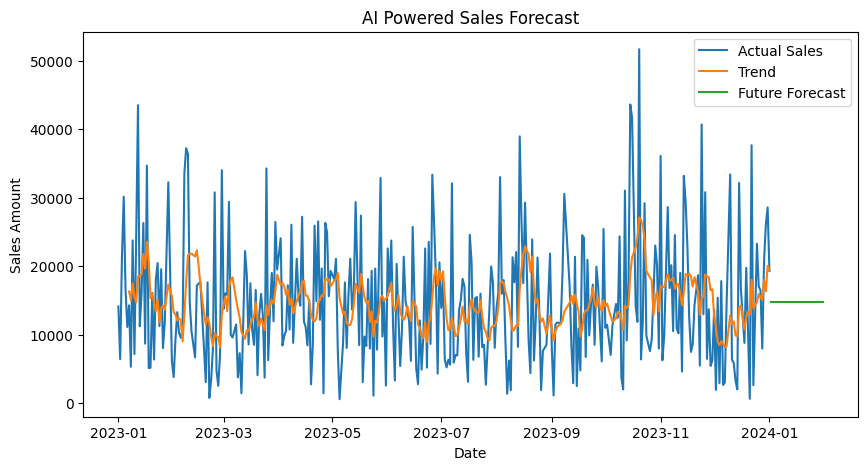

TASK 1 COMPLETED SUCCESSFULLY


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sales_data.csv", encoding="latin1")
print("Before cleaning:", df.shape)
df = df[['Sale_Date', 'Sales_Amount']]
df['Sale_Date'] = pd.to_datetime(df['Sale_Date'], errors='coerce')
df['Sales_Amount'] = (
    df['Sales_Amount']
    .astype(str)
    .str.replace(",", "")
    .str.replace("₹", "")
    .str.strip())

df['Sales_Amount'] = pd.to_numeric(df['Sales_Amount'], errors='coerce')
df = df.dropna()

print("After cleaning:", df.shape)
print(df.head())

df = df.groupby('Sale_Date')['Sales_Amount'].sum().reset_index()
df['Trend'] = df['Sales_Amount'].rolling(window=7).mean()

future_days = 30
last_date = df['Sale_Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1),periods=future_days)
future_sales = [df['Sales_Amount'].mean()] * future_days
future_df = pd.DataFrame({'Date': future_dates,'Forecast_Sales': future_sales})

plt.figure(figsize=(10,5))
plt.plot(df['Sale_Date'], df['Sales_Amount'], label='Actual Sales')
plt.plot(df['Sale_Date'], df['Trend'], label='Trend')
plt.plot(future_df['Date'], future_df['Forecast_Sales'], label='Future Forecast')
plt.legend()
plt.title("AI Powered Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales Amount")
plt.show()
future_df.to_csv("forecast.csv", index=False)
print("TASK 1 COMPLETED SUCCESSFULLY")